# <font color='blue'>Machine Learning - Clusterização</font>
# <font color='blue'>Segmentação de Clientes de Shopping por Perfil de Consumo</font>

**Disciplina:** Tópicos Especiais em TI

**Técnica:** Aprendizado Não Supervisionado - K-Means Clustering

**Dataset real (Kaggle):** Mall Customer Segmentation Data
Fonte: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

### Objetivo
A partir de dados reais de clientes de um shopping center (idade, gênero, renda anual e
pontuação de gastos), nosso trabalho é agrupar os clientes por similaridade de comportamento
de consumo, a fim de identificar perfis (personas) que possam orientar estratégias de marketing
segmentado.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Carga e Exploração dos Dados

In [2]:
# Carregando os dados reais baixados do Kaggle
dataset = pd.read_csv('Mall_Customers.csv')
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Dimensões do dataset
dataset.shape

(200, 5)

In [4]:
# Tipos de dados e informações gerais
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
# Checando valores ausentes
dataset.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Estatísticas descritivas das variáveis numéricas
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Não há valores ausentes. O dataset possui 200 clientes com 5 colunas:
CustomerID, Gender, Age, Annual Income (k$) e Spending Score (1-100).

## 2. Análise Exploratória

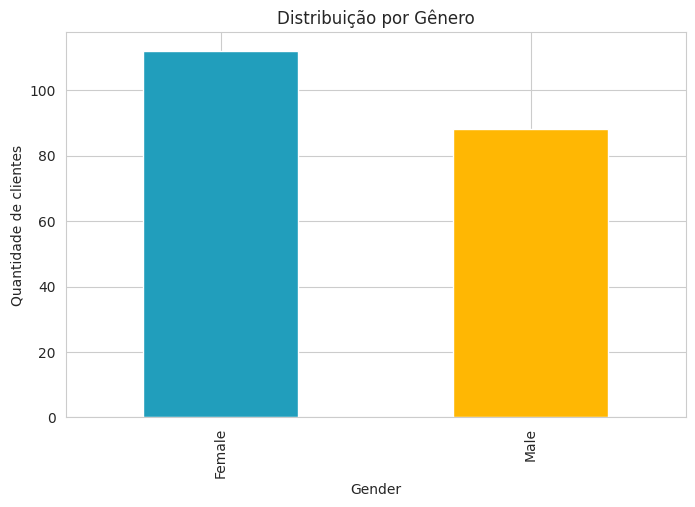

In [7]:
# Distribuição por gênero
dataset['Gender'].value_counts().plot(kind='bar', color=['#219ebc', '#ffb703'], title='Distribuição por Gênero')
plt.ylabel('Quantidade de clientes')
plt.show()

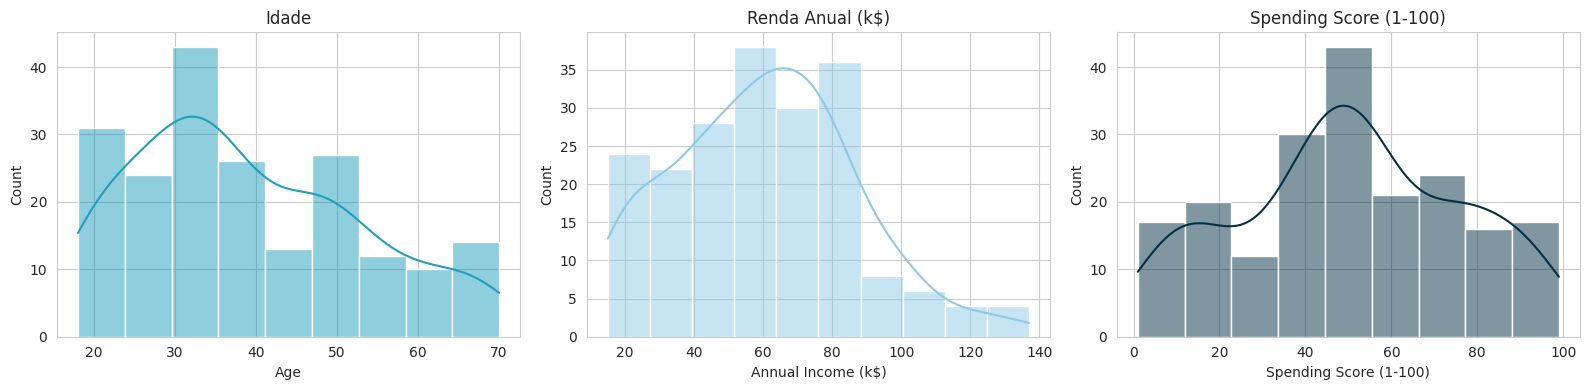

In [8]:
# Distribuição das variáveis numéricas
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(dataset['Age'], kde=True, ax=axs[0], color='#219ebc')
axs[0].set_title('Idade')
sns.histplot(dataset['Annual Income (k$)'], kde=True, ax=axs[1], color='#8ecae6')
axs[1].set_title('Renda Anual (k$)')
sns.histplot(dataset['Spending Score (1-100)'], kde=True, ax=axs[2], color='#023047')
axs[2].set_title('Spending Score (1-100)')
plt.tight_layout()
plt.show()

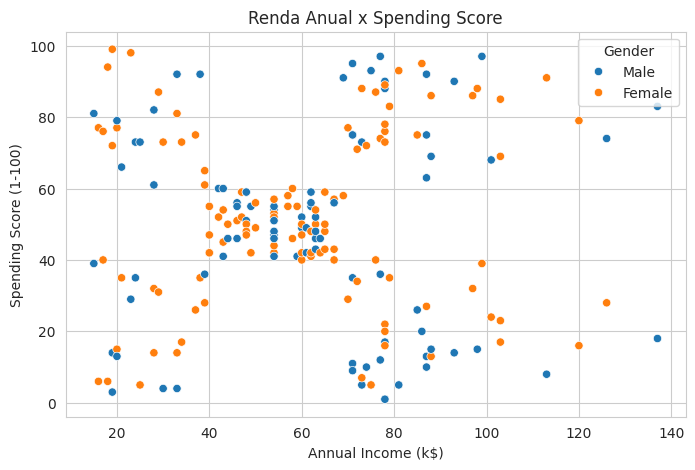

In [9]:
# Relação entre Renda Anual e Spending Score, colorido por gênero
sns.scatterplot(data=dataset, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.title('Renda Anual x Spending Score')
plt.show()

Já é possível notar visualmente alguns agrupamentos de clientes (ex: renda alta com gasto alto,
renda alta com gasto baixo, renda baixa com gasto alto, etc). Vamos usar o K-Means para
identificar esses grupos de forma objetiva.

## 3. Preparação dos Dados para Clusterização

In [10]:
# Selecionamos as variáveis Renda Anual e Spending Score, que são as mais relevantes
# para entender o comportamento de consumo dos clientes
X = dataset[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Padronizando os dados (média 0, desvio padrão 1) para que a escala não distorça as distâncias do K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## 4. Definindo o Número Ideal de Clusters (K)

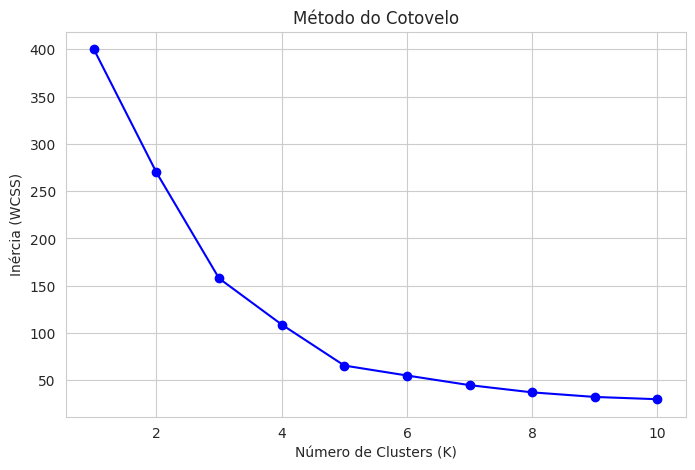

In [11]:
# Método do Cotovelo (Elbow Method): testamos vários valores de K e observamos
# a Soma dos Quadrados Intra-Cluster (inércia)
inercia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.plot(k_range, inercia, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo')
plt.show()

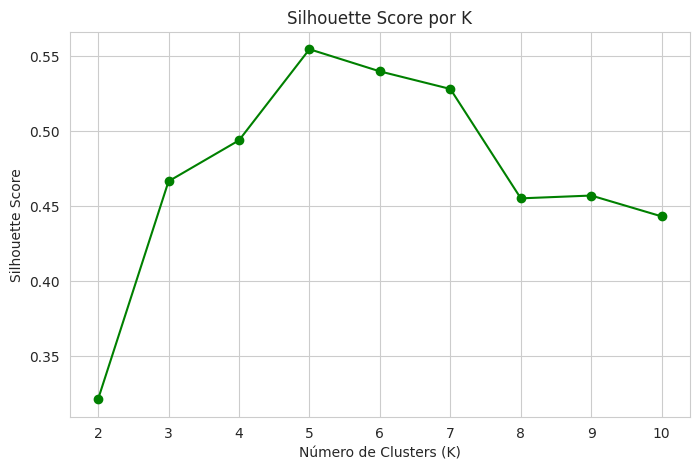

K = 2: Silhouette Score = 0.3213
K = 3: Silhouette Score = 0.4666
K = 4: Silhouette Score = 0.4939
K = 5: Silhouette Score = 0.5547
K = 6: Silhouette Score = 0.5399
K = 7: Silhouette Score = 0.5281
K = 8: Silhouette Score = 0.4552
K = 9: Silhouette Score = 0.4571
K = 10: Silhouette Score = 0.4432


In [12]:
# Confirmando com o Silhouette Score (mais próximo de 1 = clusters mais bem definidos)
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), silhouette_scores, 'go-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por K')
plt.show()

for k, s in zip(range(2, 11), silhouette_scores):
    print(f'K = {k}: Silhouette Score = {s:.4f}')

Tanto o Método do Cotovelo quanto o Silhouette Score indicam **K = 5** como um bom número
de clusters: a curva do cotovelo se estabiliza a partir daí e o Silhouette Score atinge um dos
valores mais altos.

## 5. Treinando o Modelo Final (K = 5)

In [13]:
K_ESCOLHIDO = 5
modelo_kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
dataset['Cluster'] = modelo_kmeans.fit_predict(X_scaled)

print('Silhouette Score final:', silhouette_score(X_scaled, dataset['Cluster']))
dataset.head()

Silhouette Score final: 0.5546571631111091


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


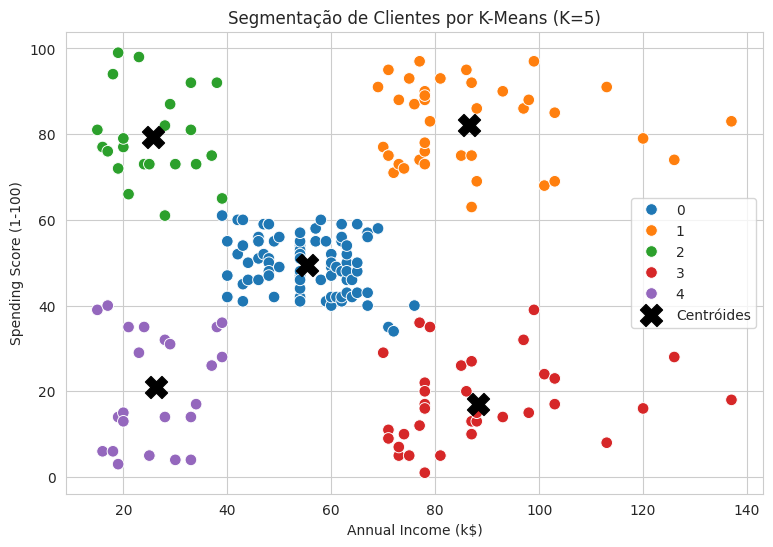

In [14]:
# Visualizando os clusters encontrados
plt.figure(figsize=(9, 6))
sns.scatterplot(data=dataset, x='Annual Income (k$)', y='Spending Score (1-100)',
                 hue='Cluster', palette='tab10', s=70)

# Centróides (revertendo a padronização para plotar na escala original)
centroides = scaler.inverse_transform(modelo_kmeans.cluster_centers_)
plt.scatter(centroides[:, 0], centroides[:, 1], marker='X', s=250, c='black', label='Centróides')
plt.title('Segmentação de Clientes por K-Means (K=5)')
plt.legend()
plt.show()

## 6. Perfil de Cada Cluster (Interpretação de Negócio)

In [15]:
perfil_clusters = dataset.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
perfil_clusters['Qtd_Clientes'] = dataset.groupby('Cluster').size()
perfil_clusters

,Age,Annual Income (k$),Spending Score (1-100),Qtd_Clientes
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


**Interpretação dos clusters encontrados:**

- **Cluster com renda baixa e gasto baixo:** clientes conservadores, provavelmente pouco
  engajados com o shopping.
- **Cluster com renda baixa e gasto alto:** clientes que gastam acima do que a renda sugeriria
  — público interessante para ações de fidelização.
- **Cluster com renda média e gasto médio:** perfil "padrão", maior parte da base de clientes.
- **Cluster com renda alta e gasto baixo:** clientes com poder de compra mas pouco engajados —
  oportunidade de campanhas direcionadas.
- **Cluster com renda alta e gasto alto:** clientes premium, público mais valioso para o shopping.

Essa segmentação permite à equipe de marketing direcionar campanhas e promoções específicas
para cada perfil de cliente, em vez de tratar toda a base de forma genérica.